**Importing libraries and the downloaded dataset**

In [18]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

print(df.head())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

**EDA and Data Preprocessing**

In [20]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("Diagnosis Distribution:")
print(df["diagnosis"].value_counts())


Dataset Shape:
(569, 32)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-

In [3]:
#removing the ID column and converting the diagnosis labels into numbers.

df = df.drop("id", axis=1)

df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

**Separating Features and Target column**

In [4]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

**Splitting Dataset into Training and Testing sets**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (455, 30)
Testing Samples: (114, 30)


**Feature Scaling**

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Training the Logistic Regression Model**

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

**Training the KNN Classification Model**

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_prediction = knn.predict(X_test)

**Evaluating the Logistic Regression model**

In [10]:
print("LOGISTIC REGRESSION")

print("Accuracy:",
      accuracy_score(y_test, lr_prediction))

print("Precision:",
      precision_score(y_test, lr_prediction))

print("Recall:",
      recall_score(y_test, lr_prediction))

print("F1 Score:",
      f1_score(y_test, lr_prediction))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_prediction))

LOGISTIC REGRESSION
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412
Confusion Matrix:
[[70  1]
 [ 2 41]]


**Evaluating the KNN Model**

In [11]:
print("K NEAREST NEIGHBORS")

print("Accuracy:",
      accuracy_score(y_test, knn_prediction))

print("Precision:",
      precision_score(y_test, knn_prediction))

print("Recall:",
      recall_score(y_test, knn_prediction))

print("F1 Score:",
      f1_score(y_test, knn_prediction))

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_prediction))

K NEAREST NEIGHBORS
Accuracy: 0.9473684210526315
Precision: 0.9302325581395349
Recall: 0.9302325581395349
F1 Score: 0.9302325581395349
Confusion Matrix:
[[68  3]
 [ 3 40]]


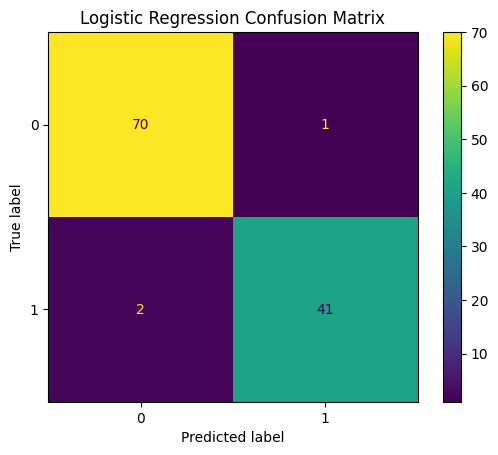

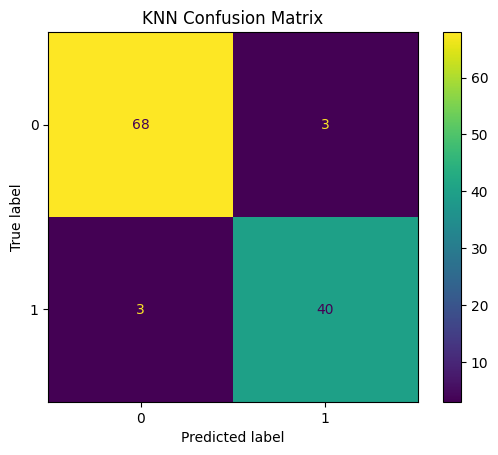

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_prediction)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, knn_prediction)
plt.title("KNN Confusion Matrix")
plt.show()


**Performance Comparison**

In [12]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, knn_prediction)
    ],

    "Precision":[
        precision_score(y_test, lr_prediction),
        precision_score(y_test, knn_prediction)
    ],

    "Recall":[
        recall_score(y_test, lr_prediction),
        recall_score(y_test, knn_prediction)
    ],

    "F1 Score":[
        f1_score(y_test, lr_prediction),
        f1_score(y_test, knn_prediction)
    ]

})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.976190  0.953488  0.964706
1                  KNN  0.947368   0.930233  0.930233  0.930233


**Better Performing Model**

In [13]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("Better Performing Model:", best_model)

Better Performing Model: Logistic Regression


**Interpretation**

1. Both Logistic Regression and K-Nearest Neighbors (KNN) classifiers performed well on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was split into 455 training samples and 114 testing samples.

2. Logistic Regression achieved an accuracy of 97.37%, which was higher than KNN's 94.74%. It also recorded better precision (97.62%), recall (95.35%), and F1 score (96.47%) compared to KNN, which achieved 93.02% for precision, recall, and F1 score.

3. The confusion matrix for Logistic Regression showed only 3 misclassified samples (1 false positive and 2 false negatives), whereas KNN misclassified 6 samples (3 false positives and 3 false negatives). This indicates that Logistic Regression made fewer prediction errors and classified both malignant and benign tumors more accurately.

Therefore, Logistic Regression is the better-performing classifier for this dataset, as it achieved higher evaluation metrics and produced fewer misclassifications than KNN.
